# Fórmulas de Otimização — Statistisches Lernen 2

**FH Kufstein Tirol — Ian Calixto**

Notebook independente com todas as fórmulas do capítulo de **Otimização** da aula (`Statistisches_Lernen_2_v4.pdf`).

---

## Índice

| # | Fórmula | Expressão-chave |
|---|---------|----------------|
| **OPT.1** | Convexidade | $f(\lambda\alpha+(1-\lambda)\beta) \leq \lambda f(\alpha)+(1-\lambda)f(\beta)$ |
| **OPT.2** | Gradient Descent (Batch) | $\theta_{t+1} = \theta_t - \eta_t \nabla f(\theta_t)$ |
| **OPT.3** | Momentum | $v_{t+1} = \beta v_t + \nabla f(\theta_t)$ |
| **OPT.4** | Nesterov Acceleration | $v_{t+1} = \beta v_t + \nabla f(\theta_t - \eta\beta v_t)$ |
| **OPT.5** | SGD com Minibatch | $\theta_{t+1} = \theta_t - \eta_t \nabla \ell_B(\theta_t)$ |
| **OPT.6** | AdaGrad | $\theta_t = \theta_{t-1} - \eta\, g_t/\sqrt{G_t+\varepsilon}$ |
| **OPT.7** | AdaDelta | $\Delta\theta_t = -\text{RMS}[\Delta\theta]_{t-1}/\text{RMS}[g]_t \cdot g_t$ |
| **OPT.8** | Adam | $\theta_t = \theta_{t-1} - \alpha\,\hat{m}_t/(\sqrt{\hat{v}_t}+\varepsilon)$ |
| **OPT.9** | Newton / L-BFGS | $\theta_{t+1} = \theta_t - H(\theta_t)^{-1}\nabla f(\theta_t)$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
np.random.seed(42)
print('Pronto.')

Pronto.


---

# OTIMIZAÇÃO — Métodos de Primeira e Segunda Ordem

*Baseado no Capítulo de Otimização: Statistisches_Lernen_2_v4.pdf*

O aprendizado de máquina é fundamentalmente um problema de **minimização de uma função de perda**:
$$\hat{\theta} = \arg\min_{\theta} f(\theta), \quad f(\theta) = \frac{1}{N}\sum_{i=1}^{N}\ell(f_\theta(x_i), y_i) + \lambda\mathcal{R}(\theta)$$

Esta seção cobre todos os métodos de otimização apresentados na aula, do Gradient Descent clássico até os otimizadores adaptativos modernos (Adam, AdaGrad) e métodos de segunda ordem (Newton, L-BFGS).

---

## Fórmula OPT.1 — Convexidade

### A Definição

Uma função $f: \mathbb{R}^d \to \mathbb{R}$ é **convexa** se, para todo $\alpha, \beta \in \mathbb{R}^d$ e todo $\lambda \in [0,1]$:

$$\boxed{f(\lambda\alpha + (1-\lambda)\beta) \leq \lambda f(\alpha) + (1-\lambda)f(\beta)}$$

**Geometricamente:** a linha que conecta dois pontos quaisquer do gráfico de $f$ está sempre **acima ou sobre** o gráfico.

### Por que importa para otimização?

| Função convexa | Função não-convexa |
|---------------|--------------------|
| Qualquer mínimo local é **global** | Mínimos locais ≠ mínimo global |
| Gradient Descent converge para o ótimo | GD pode ficar preso em mínimos locais |
| Garantias teóricas de convergência | Otimização é NP-hard em geral |

### Funções convexas comuns em ML

| Função | É convexa? |
|--------|------------|
| MSE (regressão linear) | ✅ Sim |
| Ridge: $\text{MSE} + \lambda\|\theta\|^2$ | ✅ Sim |
| Lasso: $\text{MSE} + \lambda\|\theta\|_1$ | ✅ Sim |
| Redes neurais profundas | ❌ Não em geral |

> **Insight prático:** em redes neurais sobredimensionadas a maioria dos mínimos locais tem perda similar ao global. O problema real são **regiões de sela**, das quais o SGD com ruído ajuda a escapar.

## Fórmula OPT.2 — Gradient Descent (Batch)

### A Fórmula

$$\boxed{\theta_{t+1} = \theta_t - \eta_t \nabla f(\theta_t)}$$

| Símbolo | Significado |
|---------|-------------|
| $\theta_t$ | Parâmetros na iteração $t$ |
| $\eta_t > 0$ | **Learning rate** — tamanho do passo |
| $\nabla f(\theta_t)$ | Gradiente da loss — direção de maior crescimento |
| $-\nabla f(\theta_t)$ | **Direção de descida** — move-se para minimizar $f$ |

### Dedução Intuitiva

Pela expansão de Taylor de 1ª ordem:
$$f(\theta_{t+1}) \approx f(\theta_t) - \eta_t \|\nabla f(\theta_t)\|^2 < f(\theta_t)$$

(válido para $\eta_t$ suficientemente pequeno)

### Estratégias de Learning Rate

| Estratégia | Fórmula | Quando usar |
|------------|---------|-------------|
| **Fixo** | $\eta_t = \eta$ | Simples, pode divergir ou convergir lento |
| **Step Decay** | $\eta_t = \eta_0 \cdot \gamma^{\lfloor t/k \rfloor}$ | Reduzir após $k$ épocas |
| **Cosine Decay** | $\eta_t = \eta_{\min} + \tfrac{1}{2}(\eta_0-\eta_{\min})(1+\cos(\pi t/T))$ | Estado da arte |
| **Line Search** | Armijo / Wolfe conditions | Problemas convexos |

> **Custo:** cada iteração processa **todos os $N$ dados** — caro para datasets grandes. Solução: SGD com minibatch (OPT.5).

## Fórmula OPT.3 — Momentum

### A Fórmula

$$\boxed{v_{t+1} = \beta v_t + \nabla f(\theta_t), \qquad \theta_{t+1} = \theta_t - \eta_t v_{t+1}}$$

| Símbolo | Significado |
|---------|-------------|
| $v_t$ | **Velocity** — acumulado ponderado dos gradientes passados |
| $\beta$ | Fator de momentum ($\approx 0.9$ típico) |

### Intuição Física

Uma bola rolando em um vale: sem momentum ela muda de direção bruscamente. Com momentum **acumula velocidade** nas direções consistentes e **amorte oscilações** transversais.

Expandindo: $v_{t+1} = \nabla f(\theta_t) + \beta \nabla f(\theta_{t-1}) + \beta^2 \nabla f(\theta_{t-2}) + \ldots$ → **EMA dos gradientes**.

### Por que é usado?

1. **Acelera a convergência** em vales estreitos e longos
2. **Amorte oscilações** em direções com alta curvatura
3. Pode escapar de mínimos locais rasos por inércia

---

## Fórmula OPT.4 — Nesterov Acceleration

$$\boxed{v_{t+1} = \beta v_t + \nabla f(\theta_t - \eta\beta v_t), \qquad \theta_{t+1} = \theta_t - \eta v_{t+1}}$$

O gradiente é calculado na **posição projetada** $\theta_t - \eta\beta v_t$ (onde chegaríamos com o passo de momentum), não na posição atual.

> **Intuição:** "olhar adiante antes de calcular o gradiente" — evita overshooting. Tem garantias de convergência melhores que o Momentum clássico para funções convexas suaves.

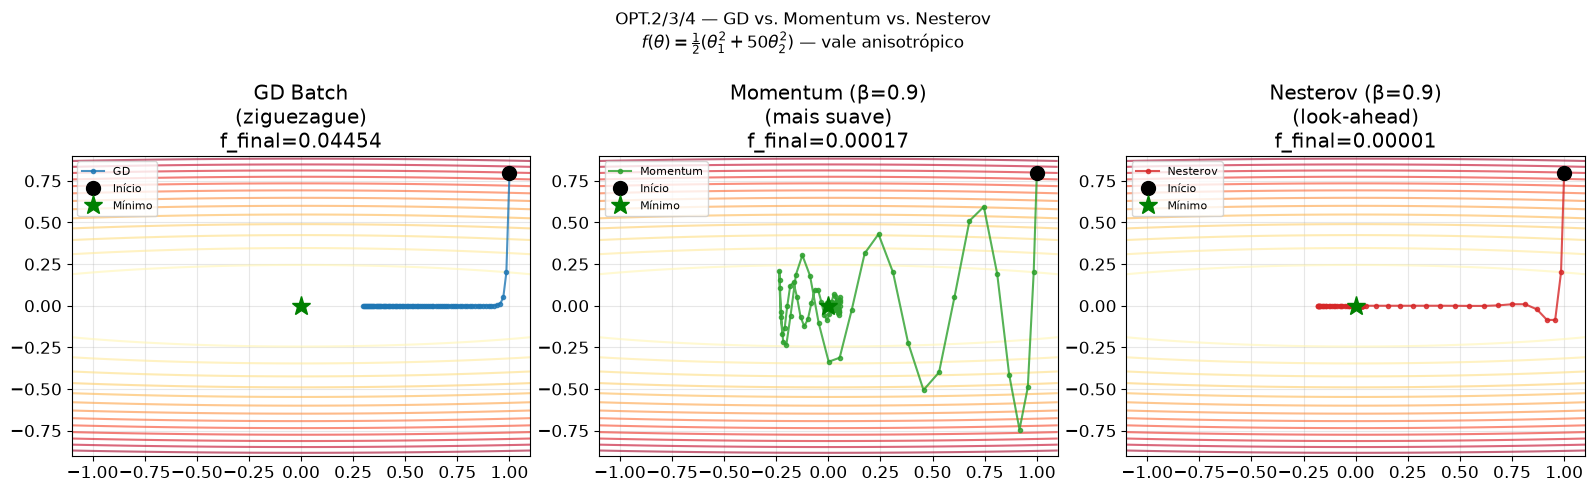

GD final:       f = 0.044542,  θ = [2.98468457e-01 5.47382213e-49]
Momentum final: f = 0.000172,  θ = [-0.01254214  0.00193421]
Nesterov final: f = 0.000012,  θ = [-4.91172154e-03 -4.07087285e-27]


In [2]:
# GD vs. Momentum vs. Nesterov em vale anisotrópico (f = 0.5*(θ₁² + 50θ₂²))
import numpy as np
import matplotlib.pyplot as plt

def f_aniso(theta): return 0.5*(theta[0]**2 + 50*theta[1]**2)
def grad_aniso(theta): return np.array([theta[0], 50*theta[1]])

def run_gd(theta0, eta, n):
    path = [theta0.copy()]; theta = theta0.copy()
    for _ in range(n):
        theta = theta - eta * grad_aniso(theta)
        path.append(theta.copy())
    return np.array(path)

def run_momentum_aniso(theta0, eta, beta, n):
    path = [theta0.copy()]; theta = theta0.copy(); v = np.zeros(2)
    for _ in range(n):
        v = beta * v + grad_aniso(theta)
        theta = theta - eta * v
        path.append(theta.copy())
    return np.array(path)

def run_nesterov(theta0, eta, beta, n):
    path = [theta0.copy()]; theta = theta0.copy(); v = np.zeros(2)
    for _ in range(n):
        v = beta * v + grad_aniso(theta - eta * beta * v)
        theta = theta - eta * v
        path.append(theta.copy())
    return np.array(path)

theta0 = np.array([1.0, 0.8])
n_steps = 80

p_gd  = run_gd(theta0, eta=0.015, n=n_steps)
p_mom = run_momentum_aniso(theta0, eta=0.015, beta=0.9, n=n_steps)
p_nes = run_nesterov(theta0, eta=0.015, beta=0.9, n=n_steps)

T1, T2 = np.meshgrid(np.linspace(-1.1, 1.1, 200), np.linspace(-0.9, 0.9, 200))
Z = 0.5*(T1**2 + 50*T2**2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, path, title, color, label in zip(
    axes,
    [p_gd, p_mom, p_nes],
    ['GD Batch\n(ziguezague)', 'Momentum (β=0.9)\n(mais suave)', 'Nesterov (β=0.9)\n(look-ahead)'],
    ['tab:blue', 'tab:green', 'tab:red'],
    ['GD', 'Momentum', 'Nesterov']
):
    ax.contour(T1, T2, Z, levels=18, cmap='YlOrRd', alpha=0.6)
    ax.plot(path[:,0], path[:,1], '-o', color=color, ms=3, lw=1.5, alpha=0.8, label=label)
    ax.plot(*theta0, 'ko', ms=10, zorder=5, label='Início')
    ax.plot(0, 0, 'g*', ms=14, zorder=5, label='Mínimo')
    ax.set_title(f'{title}\nf_final={f_aniso(path[-1]):.5f}')
    ax.legend(fontsize=8); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-0.9, 0.9)

plt.suptitle('OPT.2/3/4 — GD vs. Momentum vs. Nesterov\n'
             '$f(\\theta) = \\frac{1}{2}(\\theta_1^2 + 50\\theta_2^2)$ — vale anisotrópico', fontsize=12)
plt.tight_layout(); plt.show()

print(f"GD final:       f = {f_aniso(p_gd[-1]):.6f},  θ = {p_gd[-1]}")
print(f"Momentum final: f = {f_aniso(p_mom[-1]):.6f},  θ = {p_mom[-1]}")
print(f"Nesterov final: f = {f_aniso(p_nes[-1]):.6f},  θ = {p_nes[-1]}")

## Fórmula OPT.5 — Stochastic Gradient Descent (SGD) com Minibatch

### A Fórmula

Em vez do gradiente completo, usa um **gradiente estimado sobre um minibatch** $B$:

$$\nabla \ell_B(\theta_t) = \frac{1}{|B|} \sum_{z \in B} \nabla \ell(\theta_t; z)$$

$$\boxed{\theta_{t+1} = \theta_t - \eta_t \nabla \ell_B(\theta_t)}$$

### Pseudocódigo SGD

```
Input: dataset D, loss ℓ, θ₀, learning rates ηₜ, batch size m

for epoch = 1, 2, ...:
    shuffle D                              ← embaralhar evita bias sistemático
    for each minibatch B of size m:
        g = (1/|B|) Σ_{z in B} ∇ℓ(θ; z)  ← gradiente do minibatch
        θ = θ - ηₜ g                       ← atualização
    end
end
```

### Casos Especiais

| Variante | Tamanho do batch | Alias |
|----------|-----------------|-------|
| **Full-batch GD** | $|B| = N$ (todos os dados) | "Gradient Descent" clássico |
| **Mini-batch SGD** | $|B| \in [32, 512]$ | "SGD" na prática |
| **Online SGD** | $|B| = 1$ | Stochastic GD original |

### Escolhas Práticas

| Hiperparâmetro | Efeito | Guia Típico |
|----------------|--------|-------------|
| **Batch size** | Controla ruído e eficiência no hardware | Potências de 2; batches maiores → learning rates maiores |
| **Learning rate decay** | Reduz ruído perto do ótimo | Cosine ou step decay — usar curvas de validação |
| **Shuffling** | Evita bias sistemático | Embaralhar a cada época |
| **Early stopping** | Age como regularização | Monitorar loss de validação, não só de treino |

### Por que o ruído pode ser útil?

O gradiente de minibatch é um **estimador não-viesado** do gradiente completo:
$$\mathbb{E}_B[\nabla \ell_B(\theta)] = \nabla f(\theta)$$

O ruído com variância $\propto \sigma^2/|B|$ pode ajudar a **escapar de mínimos locais rasos e regiões de sela** — motivo pelo qual SGD é o método dominante para treinar redes neurais em larga escala.

## Fórmula OPT.6 — AdaGrad (Adaptive Gradient)

### A Fórmula

$$g_t = \nabla_\theta \ell_{B_t}(\theta_{t-1}), \qquad G_t = G_{t-1} + g_t \odot g_t$$

$$\boxed{\theta_t = \theta_{t-1} - \eta \frac{g_t}{\sqrt{G_t + \varepsilon}}}$$

Forma explícita por coordenada $i$:
$$\theta_{t,i} = \theta_{t-1,i} - \eta \frac{g_{t,i}}{\sqrt{G_{t,i} + \varepsilon}}$$

| Símbolo | Significado |
|---------|-------------|
| $G_t$ | **Soma acumulada** dos quadrados dos gradientes (por coordenada) |
| $\odot$ | Produto elemento a elemento (Hadamard) |
| $\varepsilon$ | Constante de estabilidade numérica ($\approx 10^{-8}$) |
| $\eta / \sqrt{G_{t,i}}$ | Learning rate efetivo para a coordenada $i$ |

### Intuição

AdaGrad é um **pré-condicionador diagonal**: rescala cada coordenada pela magnitude histórica dos seus gradientes.

- **Coordenadas com gradientes grandes/frequentes** → $G_{t,i}$ cresce → passos menores
- **Features raras/esparsas** → $G_{t,i}$ pequeno → passos maiores → aprendizado mais agressivo onde os dados são escassos

### Quando funciona bem / Limitação

✅ Problemas **esparsos** de alta dimensão (NLP, features de texto, sistemas de recomendação)

❌ **Learning rates só decrescem** — após muitas iterações, os passos ficam minúsculos e o modelo para de aprender. → AdaDelta e Adam corrigem este problema.

## Fórmula OPT.7 — AdaDelta (Windowed Adaptation)

### A Fórmula

$$\mathbb{E}[g^2]_t = \rho \,\mathbb{E}[g^2]_{t-1} + (1-\rho)\, g_t^2$$

$$\text{RMS}[g]_t = \sqrt{\mathbb{E}[g^2]_t + \varepsilon}, \qquad \text{RMS}[\Delta\theta]_t = \sqrt{\mathbb{E}[\Delta\theta^2]_t + \varepsilon}$$

$$\boxed{\Delta\theta_t = -\frac{\text{RMS}[\Delta\theta]_{t-1}}{\text{RMS}[g]_t}\, g_t, \qquad \theta_t = \theta_{t-1} + \Delta\theta_t}$$

$$\mathbb{E}[\Delta\theta^2]_t = \rho\, \mathbb{E}[\Delta\theta^2]_{t-1} + (1-\rho)\,\Delta\theta_t^2$$

| Símbolo | Significado |
|---------|-------------|
| $\rho$ | Fator de decaimento EMA ($\approx 0.95$ típico) |
| $\mathbb{E}[g^2]_t$ | EMA dos gradientes ao quadrado |
| $\mathbb{E}[\Delta\theta^2]_t$ | EMA das atualizações ao quadrado |
| $\text{RMS}[\cdot]$ | Root Mean Square — raiz do segundo momento |

### O que muda em relação ao AdaGrad?

| AdaGrad | AdaDelta |
|---------|---------|
| Acumula **soma** de $g^2$ (cresce sempre) | Usa **EMA** de $g^2$ (esquece gradientes antigos) |
| Learning rate só decresce | Learning rate pode se recuperar |
| Requer learning rate global $\eta$ | Forma original **não** precisa de $\eta$ |

> **Mensagem chave:** AdaDelta corrige o problema do AdaGrad de passos monotonicamente decrescentes usando uma janela deslizante de gradientes recentes. $\rho \approx 0.95$ é o típico (memória longa).

## Fórmula OPT.8 — Adam (Adaptive Moment Estimation)

### A Fórmula

$$g_t = \nabla_\theta \ell_{B_t}(\theta_{t-1})$$

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t \quad \text{(1º momento — EMA do gradiente)}$$

$$v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2 \quad \text{(2º momento — EMA do gradiente²)}$$

**Correção de viés** (compensa $m_0 = v_0 = 0$ nas primeiras iterações):

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**Atualização final:**

$$\boxed{\theta_t = \theta_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}}$$

### Parâmetros Padrão

| Parâmetro | Significado | Padrão |
|-----------|-------------|--------|
| $\alpha$ | Learning rate global | $0.001$ |
| $\beta_1$ | Decaimento do 1º momento (momentum) | $0.9$ |
| $\beta_2$ | Decaimento do 2º momento (variância) | $0.999$ |
| $\varepsilon$ | Estabilidade numérica | $10^{-8}$ |

### O que cada componente faz?

| Componente | Papel |
|------------|-------|
| $m_t$ (1º momento) | **Momentum:** suaviza gradientes ruidosos, dá direção consistente |
| $v_t$ (2º momento) | **Escala adaptativa:** normaliza coordenadas com gradientes grandes |
| Correção de viés | Compensa inicialização com $m_0 = v_0 = 0$ — crucial nas primeiras iterações |

### Adam = Momentum + EMA Adaptativa

$$\text{Adam} \approx \text{Momentum} + \text{AdaGrad com EMA em vez de soma acumulada}$$

### Comparação dos Métodos Adaptativos

| Método | Estado mantido | Ponto forte | Cuidado |
|--------|---------------|-------------|---------|
| **AdaGrad** | Soma de $g^2$ | Features esparsas | Learning rate pode zerar |
| **AdaDelta** | EMA de $g^2$ e $\Delta\theta^2$ | Menos tuning de $\eta$ | Menos comum hoje |
| **Adam** | EMA de $g$ e $g^2$ | Default robusto para NNs | Pode generalizar pior que SGD em alguns casos |

> **AdamW:** para deep learning com regularização, AdamW é preferido — aplica weight decay **diretamente** sobre $\theta$, separado da atualização adaptativa.

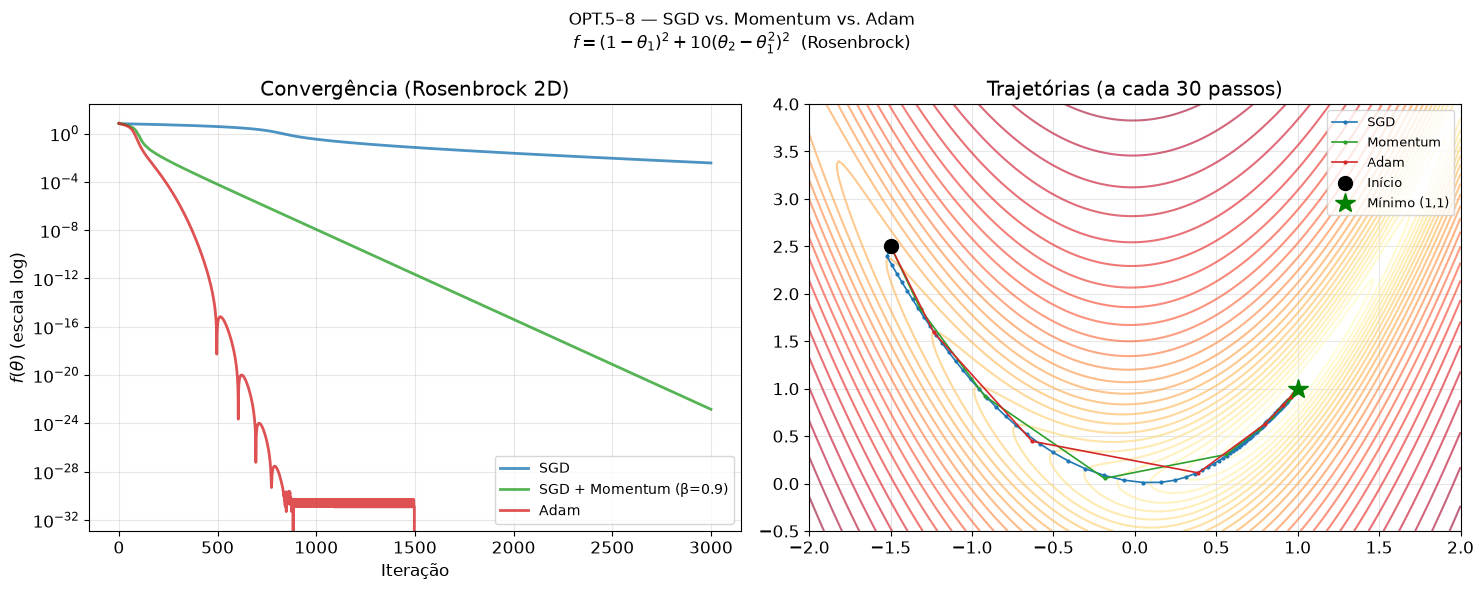

SGD final:      f = 0.003658
Momentum final: f = 0.000000
Adam final:     f = 0.00000000


In [3]:
# Comparação visual: SGD vs. Momentum vs. Adam (Função de Rosenbrock 2D)
import numpy as np
import matplotlib.pyplot as plt

def f_ros(theta):
    x, y = theta
    return (1 - x)**2 + 10*(y - x**2)**2

def grad_ros(theta):
    x, y = theta
    gx = -2*(1 - x) + 10*2*(y - x**2)*(-2*x)
    gy = 10*2*(y - x**2)
    return np.array([gx, gy])

def run_sgd(theta0, eta, n):
    path = [theta0.copy()]; theta = theta0.copy()
    for _ in range(n):
        theta = theta - eta * grad_ros(theta)
        path.append(theta.copy())
    return np.array(path)

def run_momentum(theta0, eta, beta, n):
    path = [theta0.copy()]; theta = theta0.copy(); v = np.zeros(2)
    for _ in range(n):
        v = beta * v + grad_ros(theta)
        theta = theta - eta * v
        path.append(theta.copy())
    return np.array(path)

def run_adam(theta0, alpha, b1, b2, eps, n):
    path = [theta0.copy()]; theta = theta0.copy(); m = np.zeros(2); v = np.zeros(2)
    for t in range(1, n + 1):
        g = grad_ros(theta)
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g**2
        m_hat = m / (1 - b1**t)
        v_hat = v / (1 - b2**t)
        theta = theta - alpha * m_hat / (np.sqrt(v_hat) + eps)
        path.append(theta.copy())
    return np.array(path)

theta0 = np.array([-1.5, 2.5])
n_steps = 3000

path_sgd  = run_sgd(theta0, eta=0.002, n=n_steps)
path_mom  = run_momentum(theta0, eta=0.002, beta=0.9, n=n_steps)
path_adam = run_adam(theta0, alpha=0.05, b1=0.9, b2=0.999, eps=1e-8, n=n_steps)

f_sgd  = [f_ros(p) for p in path_sgd]
f_mom  = [f_ros(p) for p in path_mom]
f_adam = [f_ros(p) for p in path_adam]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.semilogy(f_sgd,  'tab:blue',  lw=2, alpha=0.8, label='SGD')
ax.semilogy(f_mom,  'tab:green', lw=2, alpha=0.8, label='SGD + Momentum (β=0.9)')
ax.semilogy(f_adam, 'tab:red',   lw=2, alpha=0.8, label='Adam')
ax.set_xlabel('Iteração'); ax.set_ylabel('$f(\\theta)$ (escala log)')
ax.set_title('Convergência (Rosenbrock 2D)'); ax.legend(fontsize=10)

ax = axes[1]
x_g = np.linspace(-2, 2, 200); y_g = np.linspace(-0.5, 4, 200)
X, Y = np.meshgrid(x_g, y_g)
Z = (1 - X)**2 + 10*(Y - X**2)**2
ax.contour(X, Y, np.log(Z + 1), levels=30, cmap='YlOrRd', alpha=0.6)
step = 30
ax.plot(path_sgd[::step,0],  path_sgd[::step,1],  'tab:blue',  marker='.', ms=4, lw=1.2, label='SGD')
ax.plot(path_mom[::step,0],  path_mom[::step,1],  'tab:green', marker='.', ms=4, lw=1.2, label='Momentum')
ax.plot(path_adam[::step,0], path_adam[::step,1], 'tab:red',   marker='.', ms=4, lw=1.2, label='Adam')
ax.plot(*theta0, 'ko', ms=10, zorder=6, label='Início')
ax.plot(1, 1, 'g*', ms=15, zorder=6, label='Mínimo (1,1)')
ax.set_xlim(-2, 2); ax.set_ylim(-0.5, 4)
ax.set_title('Trajetórias (a cada 30 passos)'); ax.legend(fontsize=9)

plt.suptitle('OPT.5–8 — SGD vs. Momentum vs. Adam\n$f = (1-\\theta_1)^2 + 10(\\theta_2-\\theta_1^2)^2$  (Rosenbrock)', fontsize=12)
plt.tight_layout(); plt.show()

print(f"SGD final:      f = {f_ros(path_sgd[-1]):.6f}")
print(f"Momentum final: f = {f_ros(path_mom[-1]):.6f}")
print(f"Adam final:     f = {f_ros(path_adam[-1]):.8f}")

## Fórmula OPT.9 — Métodos de Segunda Ordem: Newton e Quasi-Newton

### Newton Method

Usa uma **aproximação quadrática** ao redor do ponto atual (expansão de Taylor de 2ª ordem):

$$\boxed{\theta_{t+1} = \theta_t - H(\theta_t)^{-1} \nabla f(\theta_t)}$$

| Símbolo | Significado |
|---------|-------------|
| $H(\theta_t) = \nabla^2 f(\theta_t)$ | **Hessiana** — matriz de segundas derivadas (curvatura) |
| $H^{-1} \nabla f$ | **Direção de Newton** — gradiente pré-condicionado pela curvatura |

### Por que é mais eficiente (em iterações)?

O gradiente puro só sabe "para onde ir". A Hessiana informa **quão íngremes são as curvaturas** — o Newton ajusta o passo para ser maior em direções com pouca curvatura e menor onde a curvatura é alta.

Resultado: **convergência quadrática** perto do ótimo (vs. convergência linear do GD).

### Custo computacional

| Aspecto | Custo |
|---------|-------|
| Computar $H$ | $O(d^2)$ entradas por iteração |
| Inverter $H$ | $O(d^3)$ — proibitivo para $d > 10^4$ |

### Quasi-Newton: BFGS e L-BFGS

Evita computar a Hessiana exata: **aproxima $H^{-1}$ iterativamente** a partir de diferenças de gradiente.

$$s_t = \theta_{t+1} - \theta_t, \qquad y_t = \nabla f(\theta_{t+1}) - \nabla f(\theta_t)$$

| Método | Memória | Quando usar |
|--------|---------|-------------|
| **BFGS** | $O(d^2)$ — armazena matriz completa | Problemas de porte médio |
| **L-BFGS** | $O(m \cdot d)$ — armazena apenas $m$ pares $(s_t, y_t)$ | Modelos grandes |

> L-BFGS é popular para objetivos suaves e determinísticos com muitas variáveis. É o otimizador padrão de `scipy.optimize.minimize` e usado em regressão logística do sklearn.

---

# RESUMO GERAL — Todas as Fórmulas

---

## Tabela Mestre de Fórmulas

| # | Fórmula | Expressão | Objetivo |
|---|---------|-----------|----------|
| **1.1** | Problema Estatístico | $Y = f(\mathbf{x}) + \epsilon$ | Formalizar estrutura + ruído |
| **1.2** | Forma Matricial | $\mathbf{y} = X\mathbf{a} + \boldsymbol{\epsilon}$ | Representar todos os dados de uma vez |
| **1.3** | Normal Equations | $\hat{\mathbf{a}} = (X^TX)^{-1}X^T\mathbf{y}$ | Solução analítica exata do MSE |
| **1.4** | Basis Functions | $\hat{\mathbf{a}} = (B^TB)^{-1}B^T\mathbf{y}$ | Não-linearidade preservando álgebra linear |
| **1.5** | Polynomial Basis | $B_m(x) = x^m$ | Capturar curvaturas simples |
| **1.6** | Gaussian RBF | $B_m(x) = \exp(-(x-c_m)^2/2\sigma^2)$ | Suporte local, localidade |
| **1.7** | Fourier Basis | $\sin(2\pi kx/T), \cos(2\pi kx/T)$ | Dados periódicos |
| **1.8** | B-Splines (Cox-de Boor) | $B_{m,p}(x) = \frac{x-t_m}{t_{m+p}-t_m}B_{m,p-1} + \ldots$ | Localidade + suavidade + estabilidade |
| **2.1** | Decomposição MSE | $\text{Bias}^2 + \text{Variance} + \sigma^2$ | Diagnosticar e separar fontes de erro |
| **2.2** | Bias² | $(f(x) - \mathbb{E}[\hat{f}(x)])^2$ | Erro sistemático do modelo |
| **2.3** | Variance | $\mathbb{E}[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2]$ | Sensibilidade ao dataset |
| **2.4** | K-Fold CV | $\text{CV}_K = \frac{1}{K}\sum_{k=1}^K \text{MSE}_k$ | Estimar erro de generalização |
| **3.1** | Soft Regularização | $\mathcal{L}(\theta) + \lambda\mathcal{R}(\theta)$ | Controlar complexidade |
| **3.2** | Ridge (L2) | $\hat{\theta} = (X^TX+\lambda I)^{-1}X^T\mathbf{y}$ | Encolhimento; invertibilidade |
| **3.3** | Lasso (L1) | $\min \text{MSE} + \lambda\|\theta\|_1$ | Esparsidade; feature selection |
| **3.4** | Elastic Net | $\lambda_1\|\theta\|_1 + \lambda_2\|\theta\|^2$ | Features correlacionadas |
| **3.5** | Early Stopping | $\hat{\theta}_{\text{ES}}(t) \approx \hat{\theta}_{\text{Ridge}}(1/\eta t)$ | Regularização implícita |
| **3.6** | Dropout | $\tilde{h}_j = m_j h_j$, $m_j \sim \text{Bernoulli}(1-p)$ | Ensemble implícito |
| **3.7** | Label Smoothing | $y_k^s = y_k(1-\epsilon) + \epsilon/K$ | Output regularization |
| **4.1** | Likelihood | $-\log p(\mathcal{D}\mid\theta) = \text{MSE}$ | Interpretação probabilística do MSE |
| **4.2** | Bayes | $p(\theta\mid\mathcal{D}) \propto p(\mathcal{D}\mid\theta)\cdot p(\theta)$ | Fundir prior com dados |
| **4.3** | Gaussian Prior → L2 | $\lambda = \sigma^2/\tau^2$ | Ridge como MAP com prior Gaussiano |
| **4.4** | Laplace Prior → L1 | $\lambda = \sigma^2/b$ | Lasso como MAP com prior de Laplace |
| **4.5** | Bootstrap IC | $[q_{2.5\%}(\{s^b\}), q_{97.5\%}(\{s^b\})]$ | Incerteza sem fórmulas analíticas |
| **OPT.1** | Convexidade | $f(\lambda\alpha+(1-\lambda)\beta) \leq \lambda f(\alpha)+(1-\lambda)f(\beta)$ | Garantia de mínimo global |
| **OPT.2** | Gradient Descent | $\theta_{t+1} = \theta_t - \eta_t \nabla f(\theta_t)$ | Descida iterativa pela inclinação |
| **OPT.3** | Momentum | $v_{t+1} = \beta v_t + \nabla f(\theta_t)$, $\theta_{t+1} = \theta_t - \eta_t v_{t+1}$ | EMA dos gradientes; acelerar |
| **OPT.4** | Nesterov | $v_{t+1} = \beta v_t + \nabla f(\theta_t - \eta\beta v_t)$ | Look-ahead gradient |
| **OPT.5** | SGD Minibatch | $\theta_{t+1} = \theta_t - \eta_t \nabla \ell_B(\theta_t)$ | Escalar para datasets grandes |
| **OPT.6** | AdaGrad | $G_t = G_{t-1}+g_t^2$, $\theta_t = \theta_{t-1} - \eta g_t/\sqrt{G_t+\varepsilon}$ | LR adaptativo por coordenada |
| **OPT.7** | AdaDelta | $\Delta\theta_t = -\text{RMS}[\Delta\theta]_{t-1}/\text{RMS}[g]_t \cdot g_t$ | EMA janelada; evita LR→0 |
| **OPT.8** | Adam | $\theta_t = \theta_{t-1} - \alpha\hat{m}_t/(\sqrt{\hat{v}_t}+\varepsilon)$ | Momentum + escala adaptativa |
| **OPT.9** | Newton / L-BFGS | $\theta_{t+1} = \theta_t - H^{-1}\nabla f(\theta_t)$ | Convergência quadrática com curvatura |

---

## Mapa Mental das Conexões

```
Y = f(x) + ε  (Fórmula 1.1)
│
├── Estimação de f
│   ├── Regressão Linear: â = (XᵀX)⁻¹Xᵀy  (F1.3)
│   └── Basis Functions: â = (BᵀB)⁻¹Bᵀy  (F1.4)
│       ├── Polynomial: Bm(x) = xᵐ  (F1.5)
│       ├── RBF: exp(-(x-cm)²/2σ²)  (F1.6)
│       ├── Fourier: sin/cos(2πkx/T)  (F1.7)
│       └── B-Splines: Cox-de Boor  (F1.8)
│
├── Diagnóstico do Modelo
│   └── MSE = Bias² + Variance + σ²  (F2.1, F2.2, F2.3)
│       └── Estimado via K-Fold CV = (1/K)Σ MSEk  (F2.4)
│
├── Controle da Complexidade (Regularização)
│   ├── Soft: L(θ) + λR(θ)  (F3.1)
│   │   ├── Ridge (L2): (XᵀX+λI)⁻¹Xᵀy  (F3.2)
│   │   ├── Lasso (L1): min MSE + λ||θ||₁  (F3.3)
│   │   └── Elastic Net: λ₁||θ||₁ + λ₂||θ||²  (F3.4)
│   ├── Early Stopping ≈ Ridge  (F3.5)
│   ├── Dropout: h̃j = mj·hj  (F3.6)
│   └── Label Smoothing: yk(1-ε)+ε/K  (F3.7)
│
├── Visão Probabilística
│   ├── -log Likelihood = MSE  (F4.1)
│   ├── Bayes: p(θ|D) ∝ p(D|θ)·p(θ)  (F4.2)
│   ├── Gaussian Prior → Ridge λ=σ²/τ²  (F4.3)
│   ├── Laplace Prior → Lasso λ=σ²/b  (F4.4)
│   └── Bootstrap IC = [q₂.₅%, q₉₇.₅%]  (F4.5)
│
└── Otimização (como minimizar f(θ))
    ├── Convexidade: f(λα+(1-λ)β) ≤ λf(α)+(1-λ)f(β)  (OPT.1)
    │   └── Garante que mínimo local = mínimo global
    │
    ├── Métodos de 1ª Ordem (só gradiente)
    │   ├── GD Batch: θₜ₊₁ = θₜ - ηₜ∇f(θₜ)  (OPT.2)
    │   ├── Momentum: vₜ₊₁ = βvₜ + ∇f(θₜ)  (OPT.3)  ← EMA dos gradientes
    │   ├── Nesterov: vₜ₊₁ = βvₜ + ∇f(θₜ - ηβvₜ)  (OPT.4)  ← look-ahead
    │   └── SGD Minibatch: θₜ₊₁ = θₜ - ηₜ∇ℓ_B(θₜ)  (OPT.5)  ← escala
    │
    ├── Métodos Adaptativos (LR por coordenada)
    │   ├── AdaGrad: θₜ -= η·gₜ/√(Gₜ+ε)  (OPT.6)  ← soma histórica
    │   ├── AdaDelta: θₜ += -RMS[Δθ]/RMS[g]·gₜ  (OPT.7)  ← EMA janelada
    │   └── Adam: θₜ -= α·m̂ₜ/(√v̂ₜ+ε)  (OPT.8)  ← momentum + AdaGrad com EMA
    │
    └── Métodos de 2ª Ordem (gradiente + curvatura)
        ├── Newton: θₜ₊₁ = θₜ - H(θₜ)⁻¹∇f(θₜ)  (OPT.9)
        └── L-BFGS: aproximação iterativa de H⁻¹  (OPT.9)
```

---

## Quick Reference — Fórmulas de Bolso

| Situação | Fórmula |
|----------|---------|
| Ajustar modelo linear | $\hat{\mathbf{a}} = (X^TX)^{-1}X^T\mathbf{y}$ |
| Problema mal-condicionado ($p > K$) | $\hat{\theta} = (X^TX + \lambda I)^{-1}X^T\mathbf{y}$ |
| Diagnóstico de overfitting | Gap grande treino/val → Variance alta |
| Diagnóstico de underfitting | Ambos altos → Bias² alto |
| Escolher $\lambda$ | Log-grid: `np.logspace(-5, 5, 20)` → K-Fold CV |
| Quero sparsidade | Lasso ($\lambda\|\theta\|_1$) |
| Quero encolhimento suave | Ridge ($\lambda\|\theta\|^2$) |
| Features correlacionadas | Elastic Net |
| Estimar incerteza | Bootstrap: reamostrar com reposição $B$ vezes |
| Reduzir Variance sem mais dados | Bagging / Dropout / Ridge |
| **Otimizar com muitos dados** | **SGD Minibatch:** $\theta \leftarrow \theta - \eta \nabla\ell_B(\theta)$ |
| **Acelerar SGD em vales estreitos** | **Momentum** ($\beta=0.9$): acumula velocidade |
| **Default para redes neurais** | **Adam** ($\alpha=0.001$, $\beta_1=0.9$, $\beta_2=0.999$) |
| **Deep learning com regularização** | **AdamW** (weight decay separado da adaptação) |
| **Modelos clássicos (sklearn)** | **L-BFGS** via `scipy.optimize.minimize` |
| **Verificar se o problema é convexo** | Toda soma ponderada entre pontos fica acima da curva? |

---

> **Referências:**
> - `lectures understanding/L1_General_Linear_Models_Basis_Functions.ipynb`
> - `lectures understanding/L2_Bias_Variance_Model_Selection.ipynb`
> - `lectures understanding/L3_Regularization_CrossValidation.ipynb`
> - `lectures understanding/L4_Probabilistic_View_Bayesian_Regularization.ipynb`
> - `lectures/Statistisches_Lernen_2_v4.pdf` — Capítulo de Otimização